# racetraQ 00 — Qubits for drivers

A 15-minute primer for the rest of the series. You need no quantum
background, only a little trigonometry and numpy. If you already know what
$\langle Z \rangle$ means, skip to
[notebook 01](01_the_racing_env.ipynb).

The race car of racetraQ is driven by a small quantum circuit. Ten times a
second it turns the car's sensor readings into rotation angles, runs the
circuit, and reads one score per action off the qubits. This notebook builds
that chain from the smallest piece up:

1. one qubit, one rotation: the angle sets the odds of measuring 0 or 1;
2. the score $\langle Z \rangle = P(0) - P(1)$;
3. shots: a real device only gives you coin flips, so scores are estimates;
4. the RZ rotation, which a measurement alone cannot see;
5. two qubits and the CZ gate: when one qubit can steer another;
6. one sensor, one rotation, one score;
7. four of those side by side — one block of the circuit that
   [notebook 03](03_quantum_circuits_as_q_functions.ipynb) trains.

Everything is plain numpy. At the end we check our numbers against
racetraQ's own simulator.

In [1]:
# On Binder (QuBins images) this repo arrives via nbgitpuller without being
# pip-installed; install it from GitHub only if the import fails.
try:
    import racetraq  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/JanLahmann/racetraQ

import matplotlib.pyplot as plt
import numpy as np

## 1. One qubit, one rotation

A qubit's state is two numbers, the **amplitudes** of $|0\rangle$ and
$|1\rangle$. Measuring it gives 0 or 1, with probabilities equal to the
squared size of each amplitude:

$$|\psi\rangle = a\,|0\rangle + b\,|1\rangle, \qquad P(0) = |a|^2,\quad P(1) = |b|^2 .$$

Every qubit starts in $|0\rangle = (1, 0)$. The rotation
$RY(\theta)$ moves it:

$$RY(\theta) = \begin{pmatrix} \cos\frac{\theta}{2} & -\sin\frac{\theta}{2} \\ \sin\frac{\theta}{2} & \cos\frac{\theta}{2} \end{pmatrix},
\qquad RY(\theta)\,|0\rangle = \cos\tfrac{\theta}{2}\,|0\rangle + \sin\tfrac{\theta}{2}\,|1\rangle .$$

So $P(0) = \cos^2(\theta/2)$ and $P(1) = \sin^2(\theta/2)$. At $\theta = 0$
the qubit always reads 0, at $\theta = \pi$ always 1, and at
$\theta = \pi/2$ it is a fair coin.

In [2]:
def ry(theta):
    c, s = np.cos(theta / 2), np.sin(theta / 2)
    return np.array([[c, -s], [s, c]], dtype=complex)


def rz(phi):
    return np.diag([np.exp(-0.5j * phi), np.exp(0.5j * phi)])


ket0 = np.array([1, 0], dtype=complex)


def probabilities(state):
    return np.abs(state) ** 2


for theta in (0.0, np.pi / 2, np.pi):
    state = ry(theta) @ ket0
    p0, p1 = probabilities(state)
    print(f"theta = {theta:4.2f}:  amplitudes {np.round(state.real, 3)},  "
          f"P(0) = {p0:.2f},  P(1) = {p1:.2f}")

theta = 0.00:  amplitudes [1. 0.],  P(0) = 1.00,  P(1) = 0.00
theta = 1.57:  amplitudes [0.707 0.707],  P(0) = 0.50,  P(1) = 0.50
theta = 3.14:  amplitudes [0. 1.],  P(0) = 0.00,  P(1) = 1.00


A picture helps. Physicists draw a qubit as an arrow on a sphere, the
**Bloch sphere**: $|0\rangle$ at the north pole, $|1\rangle$ at the south
pole. $RY(\theta)$ tilts the arrow by the angle $\theta$ away from the north
pole. The left plot shows a slice through the sphere with a few tilts; the
dashed line drops each arrow onto the vertical axis.

## 2. The score: $\langle Z \rangle = P(0) - P(1)$

The height of the arrow is the number the car's circuit reports for each
qubit. It is called the **expectation value of Z**, written
$\langle Z \rangle$:

$$\langle Z \rangle = (+1)\cdot P(0) + (-1)\cdot P(1) = P(0) - P(1) .$$

Count +1 for every 0 you measure and −1 for every 1, and average. It always
lies between −1 and +1. For one RY rotation it is
$\cos^2(\theta/2) - \sin^2(\theta/2) = \cos\theta$ — exactly the height of
the arrow.

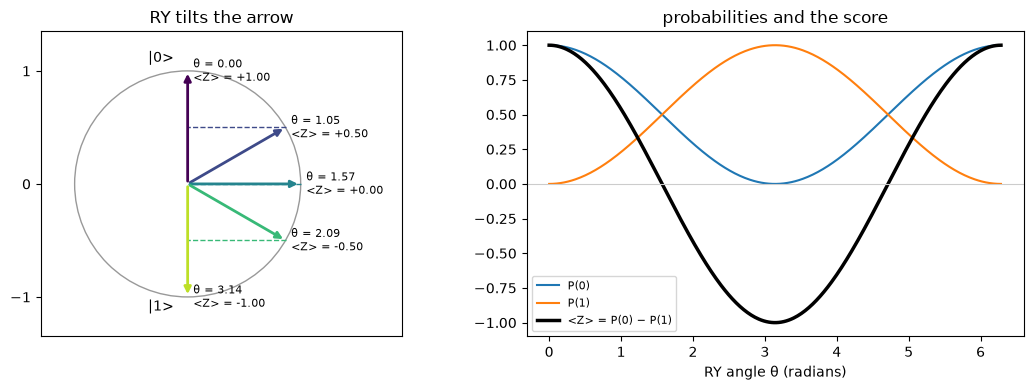

In [3]:
thetas = np.linspace(0, 2 * np.pi, 361)
p0 = np.array([probabilities(ry(t) @ ket0)[0] for t in thetas])
z = p0 - (1 - p0)
assert np.allclose(z, np.cos(thetas))  # <Z> = P(0) - P(1) = cos(theta)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.add_patch(plt.Circle((0, 0), 1, fill=False, color="0.6"))
for t, color in zip((0.0, np.pi / 3, np.pi / 2, 2 * np.pi / 3, np.pi),
                    plt.cm.viridis(np.linspace(0, 0.9, 5)), strict=True):
    x, height = np.sin(t), np.cos(t)
    ax1.annotate("", xy=(x, height), xytext=(0, 0),
                 arrowprops=dict(arrowstyle="-|>", color=color, lw=2))
    ax1.plot([x, 0], [height, height], ls="--", color=color, lw=1)
    ax1.text(x + 0.05, height, f"θ = {t:.2f}\n<Z> = {height:+.2f}", fontsize=8, va="center")
ax1.text(-0.12, 1.08, "|0>", ha="right")
ax1.text(-0.12, -1.12, "|1>", ha="right")
ax1.set(xlim=(-1.3, 1.9), ylim=(-1.35, 1.35), aspect="equal", title="RY tilts the arrow")
ax1.set_xticks([]), ax1.set_yticks([-1, 0, 1])

ax2.plot(thetas, p0, label="P(0)")
ax2.plot(thetas, 1 - p0, label="P(1)")
ax2.plot(thetas, z, lw=2.5, color="k", label="<Z> = P(0) − P(1)")
ax2.axhline(0, color="0.8", lw=0.8)
ax2.set(xlabel="RY angle θ (radians)", title="probabilities and the score")
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Shots: you only ever see coin flips

A real quantum computer does not hand you $P(0)$. Each run of the circuit —
a **shot** — ends in a single 0 or 1. To estimate $\langle Z \rangle$ you
repeat the circuit many times and average. That is a coin-flip experiment,
so we can simulate it with a random number generator.

racetraQ's hardware mode uses 1024 shots per steering decision. How far off
is a 1024-shot estimate? Statistics says the spread (standard deviation) is
$\sqrt{1 - \langle Z\rangle^2}\,/\sqrt{\text{shots}}$: about 0.03 at 1024
shots in the worst case. Let's check by sampling.

exact <Z> = 0.362
   10 shots: mean of 5000 estimates 0.363, spread 0.296 (formula: 0.295)
  100 shots: mean of 5000 estimates 0.365, spread 0.094 (formula: 0.093)


 1024 shots: mean of 5000 estimates 0.362, spread 0.029 (formula: 0.029)


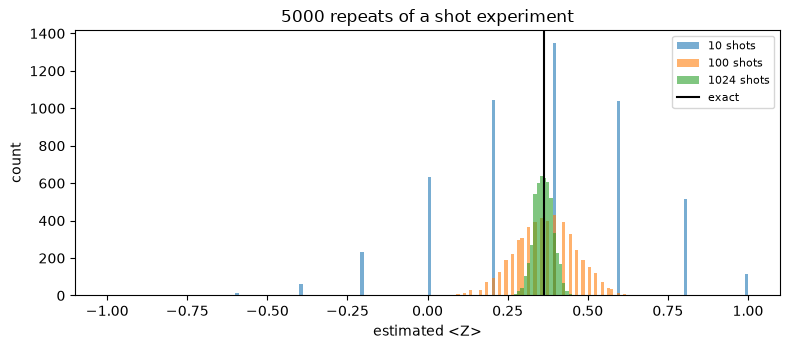

In [4]:
rng = np.random.default_rng(0)
theta = 1.2                       # some RY angle
exact = np.cos(theta)


def estimate_z(p0, shots, repeats):
    zeros = rng.binomial(shots, p0, size=repeats)   # how many shots read 0, per repeat
    return (zeros - (shots - zeros)) / shots        # (+1 per 0, -1 per 1) / shots


fig, ax = plt.subplots(figsize=(8, 3.6))
print(f"exact <Z> = {exact:.3f}")
for shots in (10, 100, 1024):
    est = estimate_z((1 + exact) / 2, shots, repeats=5000)
    theory = np.sqrt(1 - exact**2) / np.sqrt(shots)
    print(f"{shots:>5} shots: mean of 5000 estimates {est.mean():.3f}, spread {est.std():.3f} "
          f"(formula: {theory:.3f})")
    ax.hist(est, bins=np.linspace(-1, 1, 201), alpha=0.6, label=f"{shots} shots")
ax.axvline(exact, color="k", lw=1.5, label="exact")
ax.set(xlabel="estimated <Z>", ylabel="count", title="5000 repeats of a shot experiment")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

The estimates scatter around the exact value, and the spread shrinks like
one over the square root of the number of shots: 100 times more shots, 10
times less noise. (With 10 shots an estimate can only be −1, −0.8, …, +1:
hence the spikes.) This matters for driving. If the best and second-best
action scores are closer than this noise, a device can pick the wrong action.
[Notebook 05](05_real_quantum_hardware.ipynb) is about exactly that, and how
the drivers were trained to keep their scores apart. Training itself uses
exact values from a simulator, with no shots at all.

## 4. RZ: a turn the measurement cannot see

The circuit also uses a second rotation, $RZ(\varphi)$. It does not move
probability between $|0\rangle$ and $|1\rangle$; it only changes the
*phase* of the amplitudes (multiplies them by complex numbers of size 1):

$$RZ(\varphi) = \begin{pmatrix} e^{-i\varphi/2} & 0 \\ 0 & e^{i\varphi/2} \end{pmatrix} .$$

On the Bloch sphere it spins the arrow around the vertical axis. The height
stays the same. So an RZ right before a measurement changes nothing you can
measure. But an RZ *between* two RY rotations does matter: the second RY
tilts the arrow in a direction that depends on where the RZ has turned it.

RZ last:    <Z> ranges over [0.5403, 0.5403]  (cos(alpha) = 0.5403)
RZ between: <Z> ranges over [-0.227, 0.980]
fastsim's apply_ry / apply_rz agree with our 2x2 matrices


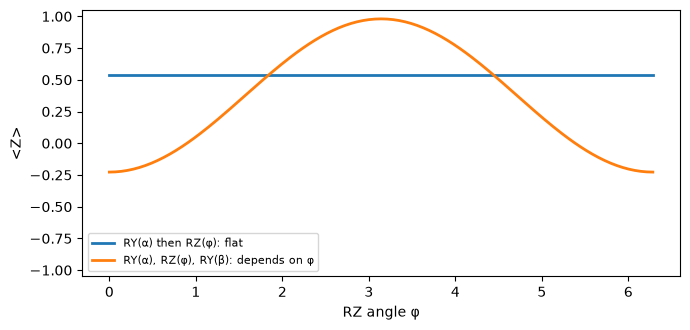

In [5]:
from racetraq.agents.quantum.fastsim import apply_ry, apply_rz


def z_of(state):
    p = probabilities(state)
    return p[0] - p[1]


alpha, beta = 1.0, 0.8
phis = np.linspace(0, 2 * np.pi, 181)
rz_last = [z_of(rz(phi) @ ry(alpha) @ ket0) for phi in phis]                  # RY, then RZ
rz_between = [z_of(ry(beta) @ rz(phi) @ ry(alpha) @ ket0) for phi in phis]    # RY, RZ, RY

print(f"RZ last:    <Z> ranges over [{min(rz_last):.4f}, {max(rz_last):.4f}]  "
      f"(cos(alpha) = {np.cos(alpha):.4f})")
print(f"RZ between: <Z> ranges over [{min(rz_between):.3f}, {max(rz_between):.3f}]")

# racetraQ's simulator implements the same gates; check that we agree with it
state = ket0[None, :].copy()            # fastsim works on a batch of states: shape (1, 2)
apply_ry(state, 0, alpha, 1)
apply_rz(state, 0, 0.7, 1)
apply_ry(state, 0, beta, 1)
assert np.allclose(state[0], ry(beta) @ rz(0.7) @ ry(alpha) @ ket0)
print("fastsim's apply_ry / apply_rz agree with our 2x2 matrices")

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(phis, rz_last, lw=2, label="RY(α) then RZ(φ): flat")
ax.plot(phis, rz_between, lw=2, label="RY(α), RZ(φ), RY(β): depends on φ")
ax.set(xlabel="RZ angle φ", ylabel="<Z>", ylim=(-1.05, 1.05))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Keep this in mind for notebook 03. The circuit there ends each qubit with an
RZ that is followed by nothing but the measurement (and diagonal CZ gates,
see next). Those RZ angles can never change a score, so training can never
change them: they are **dead parameters**.

## 5. Two qubits and the CZ gate

Two qubits have four amplitudes, one for each outcome 00, 01, 10, 11. We
store them in the order racetraQ's simulator uses: index = (qubit 0) + 2 ×
(qubit 1). With one RY on each qubit and nothing else, the state is a
**product**: the qubits are independent.

The **CZ** gate is the only two-qubit gate in the racetraQ circuit. It
flips the sign of the amplitude of $|11\rangle$ and leaves the others alone.
A sign change does not change any probability. So, on its own, a CZ changes
no measurement on either qubit. It matters only together with a rotation
*after* it: then qubit 1's angle can change what qubit 0 reads.

no CZ, RY after          <Z_0> ranges over [-0.323, -0.323] as qubit 1's angle turns
CZ, nothing after        <Z_0> ranges over [+0.540, +0.540] as qubit 1's angle turns
CZ, then RY on qubit 0   <Z_0> ranges over [-0.323, +0.995] as qubit 1's angle turns


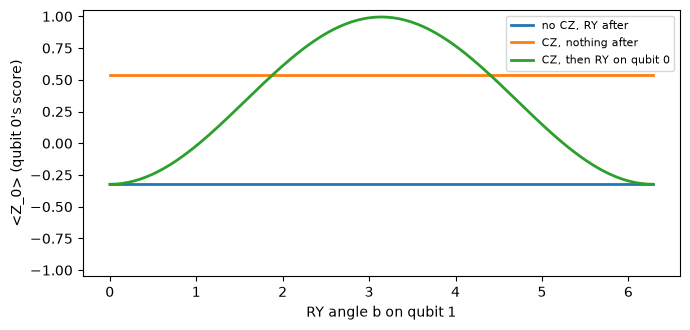

In [6]:
from racetraq.agents.quantum.fastsim import z_diagonals

CZ = np.diag([1, 1, 1, -1]).astype(complex)
I2 = np.eye(2)
Z_DIAG = z_diagonals(2)          # rows: the +1/-1 values of Z_0 and Z_1 for each outcome


def two_qubit_z(state):
    # (<Z_0>, <Z_1>) of a 2-qubit state
    return Z_DIAG @ probabilities(state)


a, c = 1.0, 0.9                  # RY angles on qubit 0: before and after the CZ
bs = np.linspace(0, 2 * np.pi, 181)  # RY angle on qubit 1
curves = {"no CZ, RY after": [], "CZ, nothing after": [], "CZ, then RY on qubit 0": []}
for b in bs:
    start = np.kron(ry(b) @ ket0, ry(a) @ ket0)       # kron(qubit 1, qubit 0) for our index order
    after = np.kron(I2, ry(c))                       # RY(c) on qubit 0 only
    curves["no CZ, RY after"].append(two_qubit_z(after @ start)[0])
    curves["CZ, nothing after"].append(two_qubit_z(CZ @ start)[0])
    curves["CZ, then RY on qubit 0"].append(two_qubit_z(after @ CZ @ start)[0])

for name, values in curves.items():
    print(f"{name:<24} <Z_0> ranges over [{min(values):+.3f}, {max(values):+.3f}] "
          "as qubit 1's angle turns")

fig, ax = plt.subplots(figsize=(7, 3.4))
for name, values in curves.items():
    ax.plot(bs, values, lw=2, label=name)
ax.set(xlabel="RY angle b on qubit 1", ylabel="<Z_0> (qubit 0's score)", ylim=(-1.05, 1.05))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Only the third curve moves. Without a CZ the qubits never interact; with a
CZ but nothing after it, the sign flip is invisible; a CZ followed by a
rotation lets qubit 1's angle steer qubit 0's score. In the third case the
formula is $\langle Z_0\rangle = \cos a \cos c - \sin a \sin c \cos b$.

When both qubits are in superposition, the CZ also creates
**entanglement**: the two-qubit state can no longer be written as one
single-qubit state times another. A quick test: arrange the four amplitudes
in a 2 × 2 table. A product state has rank 1 (every row a multiple of the
other).

In [7]:
start = np.kron(ry(np.pi / 2) @ ket0, ry(np.pi / 2) @ ket0)
for name, state in (("before the CZ", start), ("after the CZ", CZ @ start)):
    rank = np.linalg.matrix_rank(state.reshape(2, 2), tol=1e-9)
    print(f"{name}: amplitudes {np.round(state.real, 3)}, rank {rank}"
          + ("  -> product state" if rank == 1 else "  -> entangled"))

before the CZ: amplitudes [0.5 0.5 0.5 0.5], rank 1  -> product state
after the CZ: amplitudes [ 0.5  0.5  0.5 -0.5], rank 2  -> entangled


## 6. One sensor, one rotation, one score

Now the car. A sensor reading $s$ is a number in $[0, 1]$, for example the
distance ahead divided by the sensor's range. The circuit writes it into a
qubit as a rotation angle, $RY(\lambda s)$, where the **input scale**
$\lambda$ is a trainable number (it starts at $\pi$). A trainable rotation
$RY(\theta)$ follows. The qubit's score is $\langle Z\rangle$, a number in
$[-1, 1]$; a trainable weight $w$ and bias $b$ turn it into a Q-value,
$Q = w\,\langle Z\rangle + b$ (Q-values in this game reach the hundreds, so
the scale is needed).

For one qubit this is a cosine: $\langle Z\rangle = \cos(\lambda s + \theta)$.
Training turns the knobs $\lambda$, $\theta$, $w$, $b$; the plot shows what
$\theta$ does to the response.

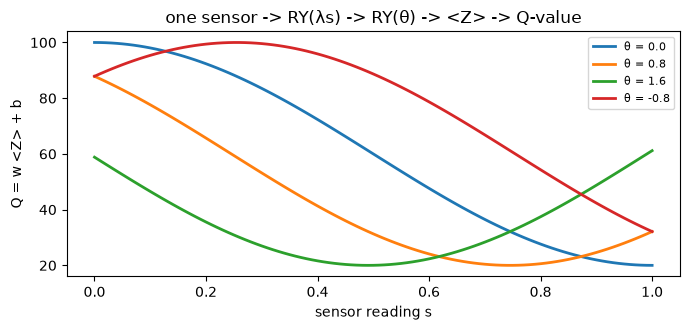

In [8]:
s = np.linspace(0, 1, 101)                 # one sensor reading, e.g. the forward ray
lam, w, b = np.pi, 40.0, 60.0              # input scale, output weight and bias

fig, ax = plt.subplots(figsize=(7, 3.4))
for theta in (0.0, 0.8, 1.6, -0.8):
    score = np.array([z_of(ry(theta) @ ry(lam * x) @ ket0) for x in s])
    assert np.allclose(score, np.cos(lam * s + theta))
    ax.plot(s, w * score + b, lw=2, label=f"θ = {theta}")
ax.set(xlabel="sensor reading s", ylabel="Q = w <Z> + b",
       title="one sensor -> RY(λs) -> RY(θ) -> <Z> -> Q-value")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

One qubit can only produce a shifted, scaled cosine of one sensor. Two things
make the real circuit richer: the qubits talk through CZ gates (section 5),
and the sensors are written in again and again, block after block
(**data re-uploading**, notebook 03).

## 7. Four qubits: one block of the racetraQ circuit

The car has four sensors: three distance rays (60° right, ahead, 60° left)
and its speed. One qubit per sensor. One **block** of the racetraQ circuit
is:

1. **encode**: $RY(\lambda_i s_i)$ on qubit $i$;
2. **rotate**: $RY(\theta_{i,0})$ then $RZ(\theta_{i,1})$ on qubit $i$;
3. **entangle**: a ring of CZ gates, 0–1, 1–2, 2–3, 3–0.

Then each of the first four qubits is measured, and its score becomes the
Q-value of one action: steer right, straight, steer left, brake. The car
takes the action with the highest Q-value.

We build one block by hand with the gate functions from section 4 and check
it against racetraQ's Q-function with a single block.

In [9]:
from racetraq.agents.quantum import QuantumQFunction
from racetraq.agents.quantum.fastsim import cz_ring_diagonal

N = 4
ACTIONS = ("steer right", "straight", "steer left", "brake")
rng = np.random.default_rng(7)
lam = np.full(N, np.pi)                       # input scales (their starting value)
theta = rng.uniform(-np.pi, np.pi, (N, 2))    # one RY and one RZ angle per qubit
w, b = np.full(N, 40.0), np.full(N, 60.0)     # output head
# [ray -60°, ray 0°, ray +60°, speed]: the observation printed in notebook 01
sensors = np.array([0.22, 1.00, 0.32, 0.82])

state = np.zeros((1, 2**N), dtype=complex)
state[0, 0] = 1.0                             # all four qubits start in |0>
for i in range(N):
    apply_ry(state, i, lam[i] * sensors[i], N)    # 1. encode
    apply_ry(state, i, theta[i, 0], N)            # 2. rotate
    apply_rz(state, i, theta[i, 1], N)
state *= cz_ring_diagonal(N)                      # 3. entangle: the CZ ring is a sign pattern
scores = z_diagonals(N) @ probabilities(state[0])
q_by_hand = w * scores + b

qf = QuantumQFunction({"n_qubits": N, "n_layers": 1})   # racetraQ's Q-function, one block
qf.lam, qf.theta, qf.w, qf.b = lam[None, :], theta[None, :, :], w, b
assert np.allclose(q_by_hand, qf.q_values(sensors[None, :])[0])

for name, z_a, q in zip(ACTIONS, scores, q_by_hand, strict=True):
    print(f"{name:<12} <Z> = {z_a:+.3f}   Q = {q:6.1f}")
print(f"-> with these random, untrained angles the car would {ACTIONS[int(np.argmax(q_by_hand))]}; "
      f"racetraQ's QuantumQFunction gives the same Q-values ({qf.n_params} parameters)")

steer right  <Z> = +0.094   Q =   63.7
straight     <Z> = +0.161   Q =   66.4
steer left   <Z> = +0.969   Q =   98.8
brake        <Z> = +0.862   Q =   94.5
-> with these random, untrained angles the car would steer left; racetraQ's QuantumQFunction gives the same Q-values (20 parameters)


With a single block, section 5 has a consequence. The CZ ring comes *after*
the last rotations, so it changes no score: each action can only see its own
sensor. The brake decision cannot see the distance ahead. The cell below
checks that by changing one sensor at a time, for 1, 2 and 3 blocks, and
compares with racetraQ's light-cone tool, which predicts the same from the
circuit's structure alone.

In [10]:
from racetraq.agents.quantum import lightcone

FEATURES = ("ray -60°", "ray 0°", "ray +60°", "speed")
rng = np.random.default_rng(1)
for layers in (1, 2, 3):
    qf = QuantumQFunction({"n_qubits": N, "n_layers": layers})
    qf.set_params(rng.uniform(-np.pi, np.pi, qf.n_params))
    base = rng.uniform(0, 1, (32, N))
    sees = np.zeros((N, N), dtype=bool)               # sees[action, feature]
    for j in range(N):
        moved = base.copy()
        moved[:, j] = rng.uniform(0, 1, 32)          # change one sensor
        sees[:, j] = np.abs(qf.expectations(moved) - qf.expectations(base)).max(axis=0) > 1e-9
    assert np.array_equal(sees, lightcone.feature_visibility(N, layers))
    seen = [name for name, ok in zip(FEATURES, sees[3], strict=True) if ok]
    print(f"{layers} block(s): brake sees {seen}")

1 block(s): brake sees ['speed']
2 block(s): brake sees ['ray -60°', 'ray +60°', 'speed']
3 block(s): brake sees ['ray -60°', 'ray 0°', 'ray +60°', 'speed']


One block: every action is blind to three of the four sensors. Two blocks:
the CZ ring of the first block, followed by the rotations of the second,
carries each sensor one qubit further around the ring. Three blocks: every
action sees every sensor. racetraQ uses four.

This is where [notebook 03](03_quantum_circuits_as_q_functions.ipynb)
begins: the same block, stacked four times with the sensors re-uploaded in
each, $4 \times (4 + 8) + 8 = 56$ trainable numbers, and the tools to see
which of them matter.

## Checkpoint

Three questions to check yourself. Answer first, then open the box.

1. A qubit's score is $\langle Z\rangle = 0$. What are $P(0)$ and $P(1)$,
   and which RY angle could have produced it?
2. You run a circuit 1024 times and read 0 in 600 of the shots. Estimate
   $\langle Z\rangle$ and how far off that estimate might be.
3. Why can the RZ angle at the very end of a qubit's line never be trained?

<details>
<summary>Answers</summary>

1. $P(0) = P(1) = 0.5$, because $\langle Z\rangle = P(0) - P(1)$ and the two
   add up to 1. $\cos\theta = 0$, so $\theta = \pi/2$ (or $-\pi/2$, $3\pi/2$, …).
2. $\langle Z\rangle \approx (600 - 424)/1024 \approx 0.17$. The spread of
   such an estimate is $\sqrt{1 - 0.17^2}/\sqrt{1024} \approx 0.03$
   (section 3), so values between about 0.11 and 0.23 are all plausible.
3. RZ only changes phases. A Z measurement sees only probabilities, and
   nothing after the final RZ (only diagonal CZ gates) turns a phase back
   into a probability. The score does not depend on that angle, so its
   gradient is exactly zero (section 4; notebook 03 measures it).

</details>

**Next:** [01 — The racing environment](01_the_racing_env.ipynb): the game
the circuit has to play.